<a href="https://colab.research.google.com/github/MartinTiong/CPE-018-CPE31S2/blob/main/Activity_6_Face_Detection_using_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2023-2024**ACTIVITY NO.** | **TITLE**
**Name** | Tiong, Martin Andrei C.
**Section** | CPE31S2
**Date Performed**: | 2/24/26
**Date Submitted**: | 2/24/26
**Instructor**: |


## 1. Objectives

This activity aims to allow students to perform face detection on still images and videos using Haar cascades.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize OpenCV to detect faces in still images and videos.
* Demonstrate the use of Haar-like features for detection of other human features.

## 3. Procedures and Outputs

Contrary to initial assumptions, conducting face detection on a static image and a video stream shares a remarkable similarity. Essentially, the latter is merely a sequential rendition of the former: when detecting faces in videos, it essentially involves applying face detection to every individual frame obtained from the camera feed. Of course, video face detection introduces additional elements like tracking, which aren't relevant to static images. Nevertheless, it's valuable to recognize that the fundamental principles behind both processes remain consistent.

### Performing face detection on still image

The first and most basic way to perform face detection is to load an image and detect faces in it. To make the result visually meaningful, we will draw rectangles around faces on the original image.

**Before implementing the code below**, check the contents of the `cv2.CascadeClassifier()` function. Provide an explanation of the function, its parameters before running the code below.

In [19]:
# Make sure that for this activity, you have downloaded the
# file indicated below from the resource linked in the instructional materials
# in the module.

import cv2
from google.colab.patches import cv2_imshow

picPath = '/content/joe joe.jpg'
haarPath = '/content/haarcascade_frontalface_default.xml'

def faceDetect(picPath):
  face_cascade = cv2.CascadeClassifier(haarPath)

  img = cv2.imread(picPath)
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray, 1.3, 5)

  for (x, y, w, h) in faces:
    img = cv2.rectangle(img, (x, y), (x+w, y+h), (255,0,0), 2)

  cv2_imshow(img)

In [20]:
import requests

url = 'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml'
r = requests.get(url, allow_redirects=True)

open('haarcascade_frontalface_default.xml', 'wb').write(r.content)

930127

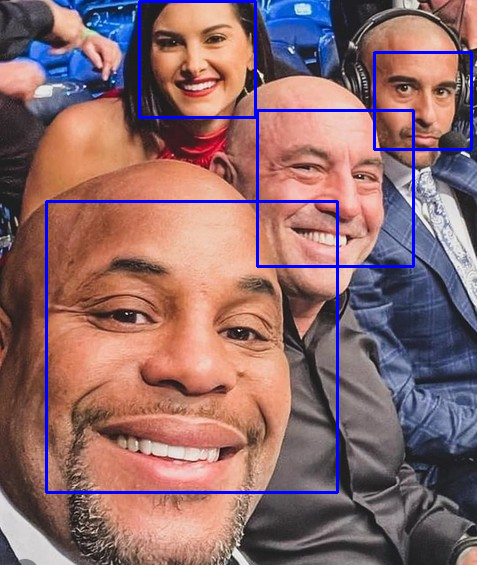

In [21]:
faceDetect(picPath)

**Analysis**:
- Based on your earlier analysis, where do you think the face detection works in the line of code above?
- Provide an analysis of the parameters of the `detectMultiScale` method.
- Change the color of the border of the detected faces to red.
- Are you able to make the borders thicker? Demonstrate.

### Performing face detection on video

**Step 1**: Create a file called face_detection.py and include the following codes.

In [33]:
import cv2

**Step 2:** After this, we declare a method, `detect()`, which will perform face detection.

In [34]:
import cv2
import os
import requests
from google.colab.patches import cv2_imshow

face_cascade_url = 'https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_frontalface_default.xml'
cascade_file = 'haarcascade_frontalface_default.xml'

if not os.path.exists(cascade_file):
    r = requests.get(face_cascade_url)
    with open(cascade_file, 'wb') as f:
        f.write(r.content)

**Step 3:** The first thing we need to do inside the detect() method is to load the Haar cascade files so that OpenCV can operate face detection. As we copied
the cascade files in the local `cascades/` folder, we can use a relative path. Then, we open a VideoCapture object (the camera feed). The VideoCapture  constructor takes a parameter, which indicates the camera to be used; zero indicates the first camera available.

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
video_path = '/content/drive/MyDrive/DATA SCI/video_20260224_173134.mp4'
cap = cv2.VideoCapture(video_path)

face_cascade = cv2.CascadeClassifier(cascade_file)

if not cap.isOpened():
    print("Error: Could not open video file.")

**Step 4:** Next up, we capture a frame. The read() method returns two values: a Boolean indicating the success of the frame read operation, and the frame
itself. We capture the frame, and then we convert it to grayscale. This is a necessary operation, because face detection in OpenCV happens in the grayscale color space:

Displaying frame 0:


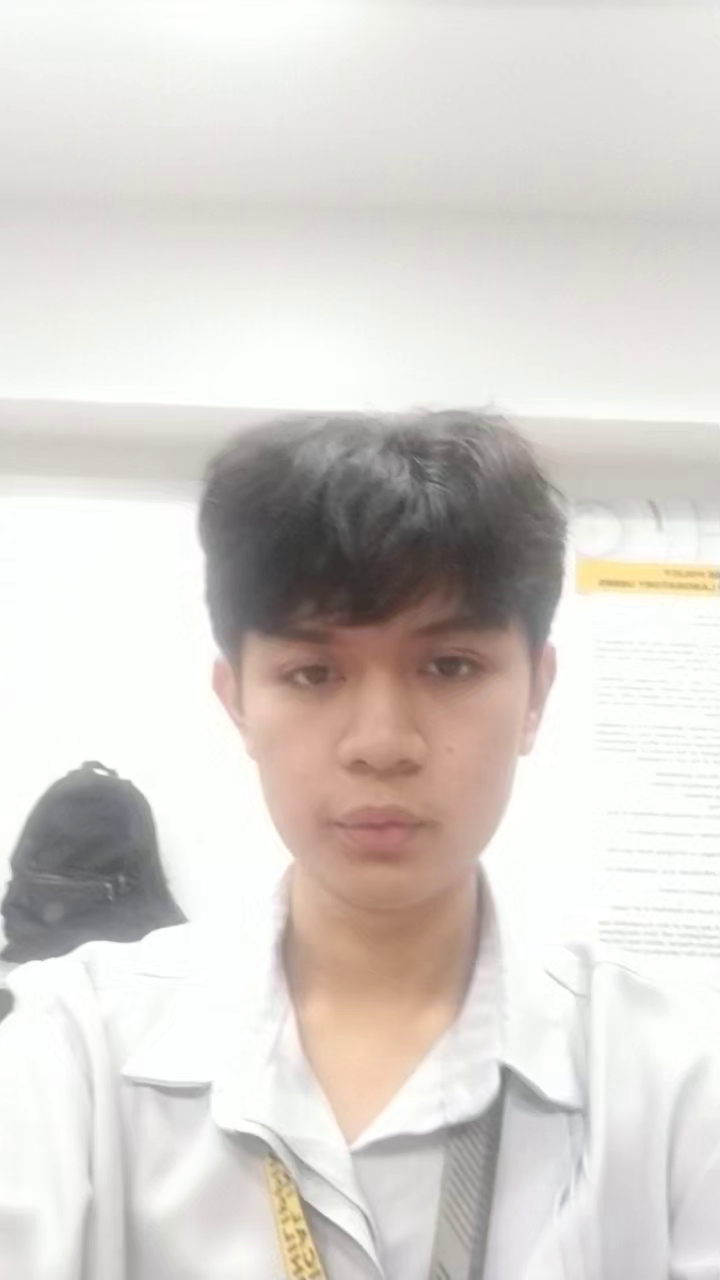

Displaying frame 30:


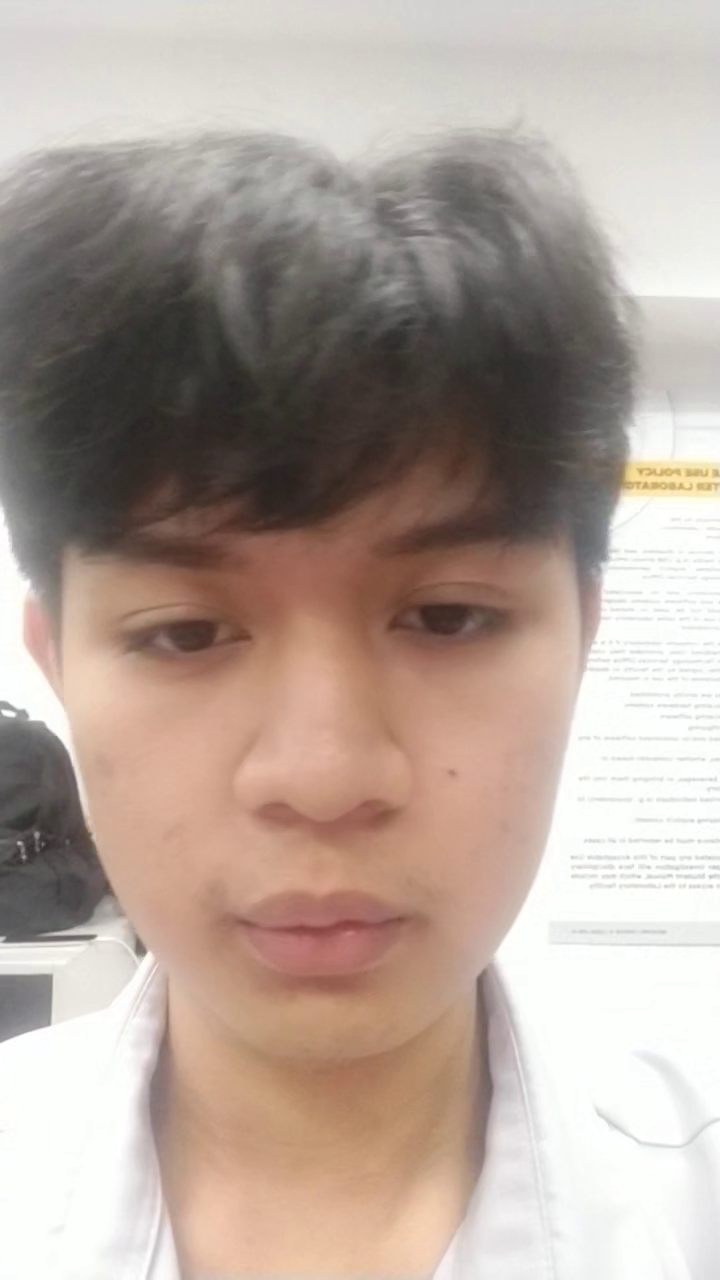

Displaying frame 60:


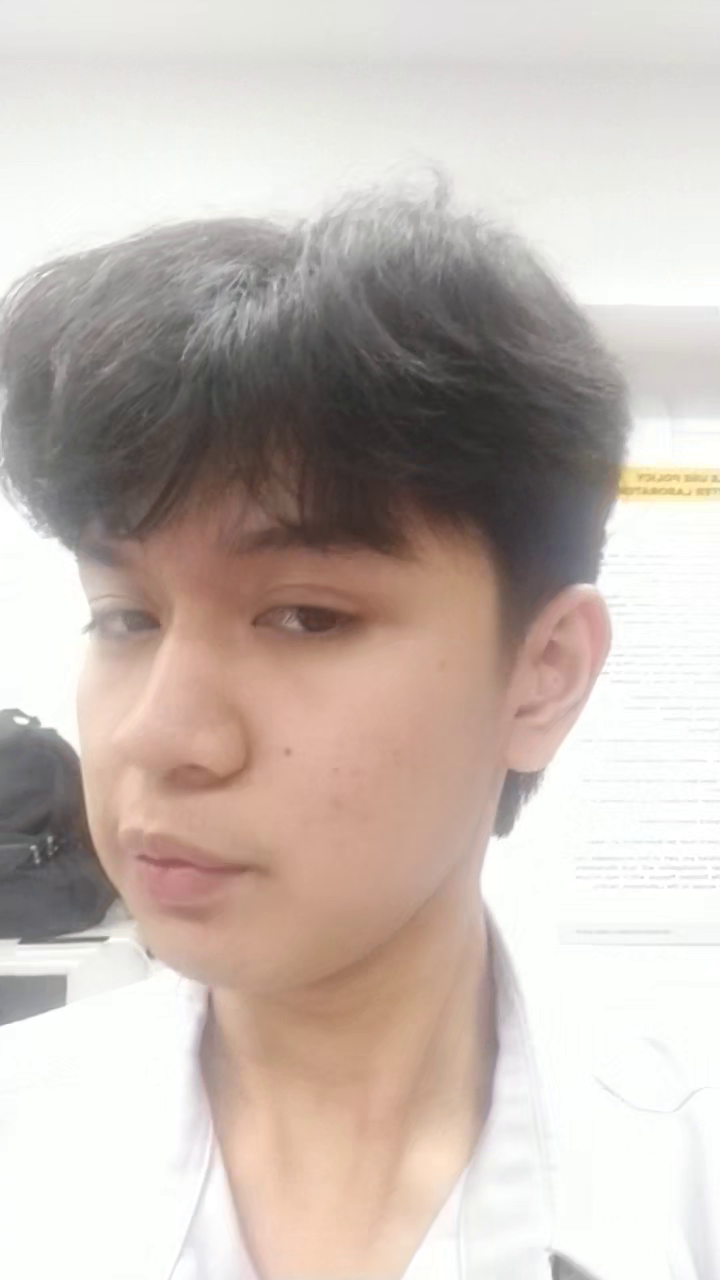

Displaying frame 90:


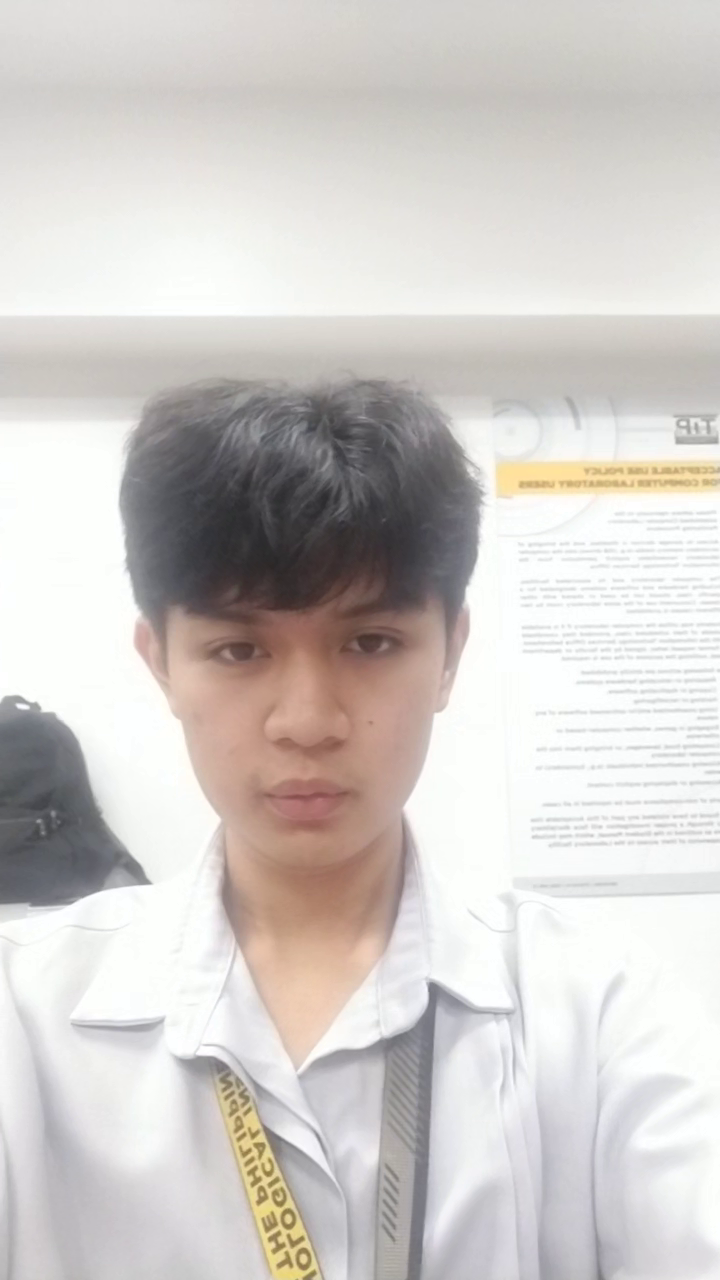

In [37]:
eye_cascade = cv2.CascadeClassifier(eye_cascade_file)

frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)


    if frame_count % 30 == 0:
        print(f"Displaying frame {frame_count}:")
        cv2_imshow(frame)

    frame_count += 1
cap.release()

**Step 5:** Much like the single still image example, we call detectMultiScale on the grayscale version of the frame.

**Step 6:** Here we have a further step compared to the still image example: we create a region of interest corresponding to the face rectangle, and within this rectangle, we operate "eye detection". This makes sense as you wouldn't want to go looking for eyes outside a face (well, for human beings at least!).

**Step 7:** Again, we loop through the resulting eye tuples and draw green rectangles around them.

In [38]:
eye_cascade_url = 'https://raw.githubusercontent.com/opencv/opencv/4.x/data/haarcascades/haarcascade_eye.xml'
eye_cascade_file = 'haarcascade_eye.xml'

if not os.path.exists(eye_cascade_file):
    r = requests.get(eye_cascade_url)
    with open(eye_cascade_file, 'wb') as f:
        f.write(r.content)

**Provide the following**:
- Screenshot of the output for the working code once you've put it all together.
- Summary of the steps you've performed along with observations.

## 4. Supplementary Activity

In your Cameo project, include real-time face detection using Haar cascade. Show screenshots of the working demonstration for this supplementary activity.

Additionally, implement similar steps to detect a smile using Haar cascades.

In [48]:
video_path = '/content/drive/MyDrive/EMTECH/video_20260224_182208.mp4'
cap = cv2.VideoCapture(video_path)

face_cascade = cv2.CascadeClassifier(cascade_file)

if not cap.isOpened():
    print("Error: Could not open video file.")

Frame 0: No faces detected.
Displaying frame 0:


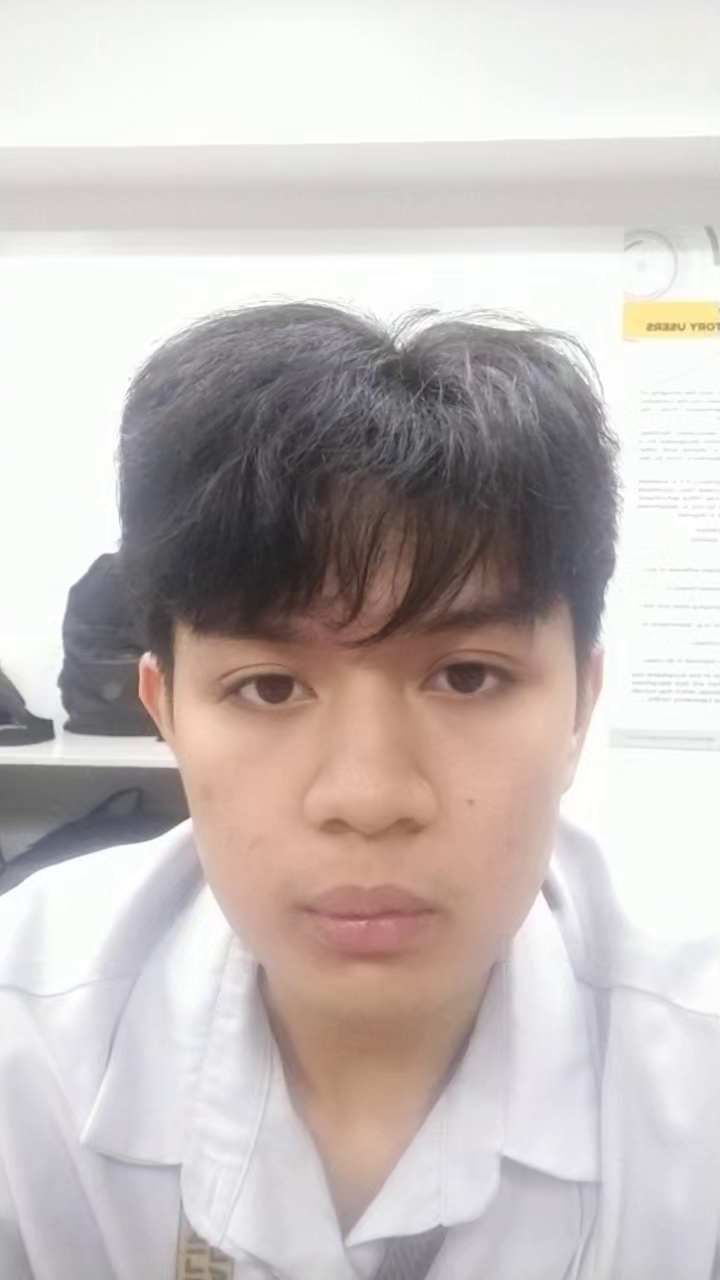

Frame 1: No faces detected.
Frame 2: No faces detected.
Frame 3: No faces detected.
Frame 4: No faces detected.
Frame 5: No faces detected.
Frame 6: No faces detected.
Frame 7: No faces detected.
Frame 8: No faces detected.
Frame 9: No faces detected.
Frame 10: No faces detected.
Frame 11: No faces detected.
Frame 12: No faces detected.
Frame 13: No faces detected.
Frame 14: No faces detected.
Frame 15: No faces detected.
Frame 16: No faces detected.
Frame 17: No faces detected.
Frame 18: No faces detected.
Frame 19: No faces detected.
Frame 20: No faces detected.
Frame 21: No faces detected.
Frame 22: No faces detected.
Frame 23: No faces detected.
Frame 24: No faces detected.
Frame 25: No faces detected.
Frame 26: No faces detected.
Frame 27: No faces detected.
Frame 28: No faces detected.
Frame 29: No faces detected.
Frame 30: No faces detected.
Displaying frame 30:


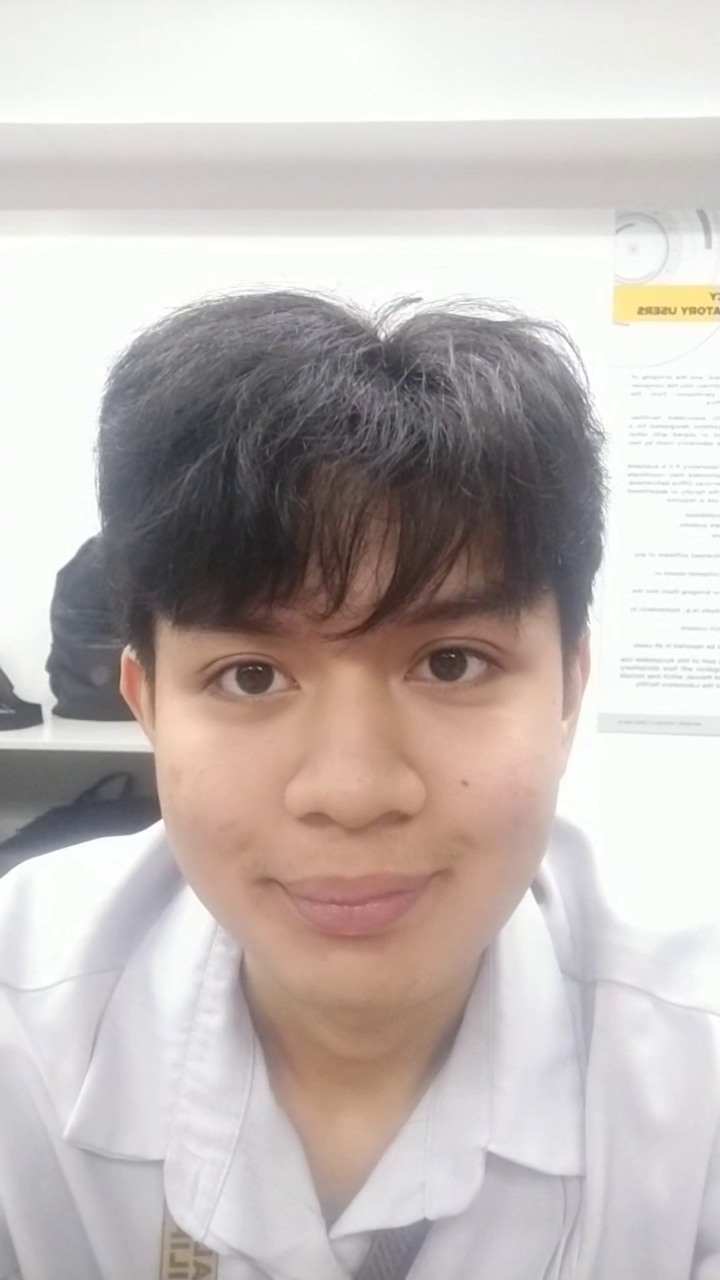

Frame 31: No faces detected.
Frame 32: No faces detected.
Frame 33: No faces detected.
Frame 34: No faces detected.
Frame 35: No faces detected.
Frame 36: No faces detected.
Frame 37: No faces detected.
Frame 38: No faces detected.
Frame 39: No faces detected.
Frame 40: No faces detected.
Frame 41: No faces detected.
Frame 42: No faces detected.
Frame 43: No faces detected.
Frame 44: No faces detected.
Frame 45: No faces detected.
Frame 46: No faces detected.
Frame 47: No faces detected.
Frame 48: No faces detected.
Frame 49: No faces detected.
Frame 50: No faces detected.
Frame 51: No faces detected.
Frame 52: No faces detected.
Frame 53: No faces detected.
Frame 54: No faces detected.
Frame 55: No faces detected.
Frame 56: No faces detected.
Frame 57: No faces detected.
Frame 58: No faces detected.
Frame 59: No faces detected.
Frame 60: No faces detected.
Displaying frame 60:


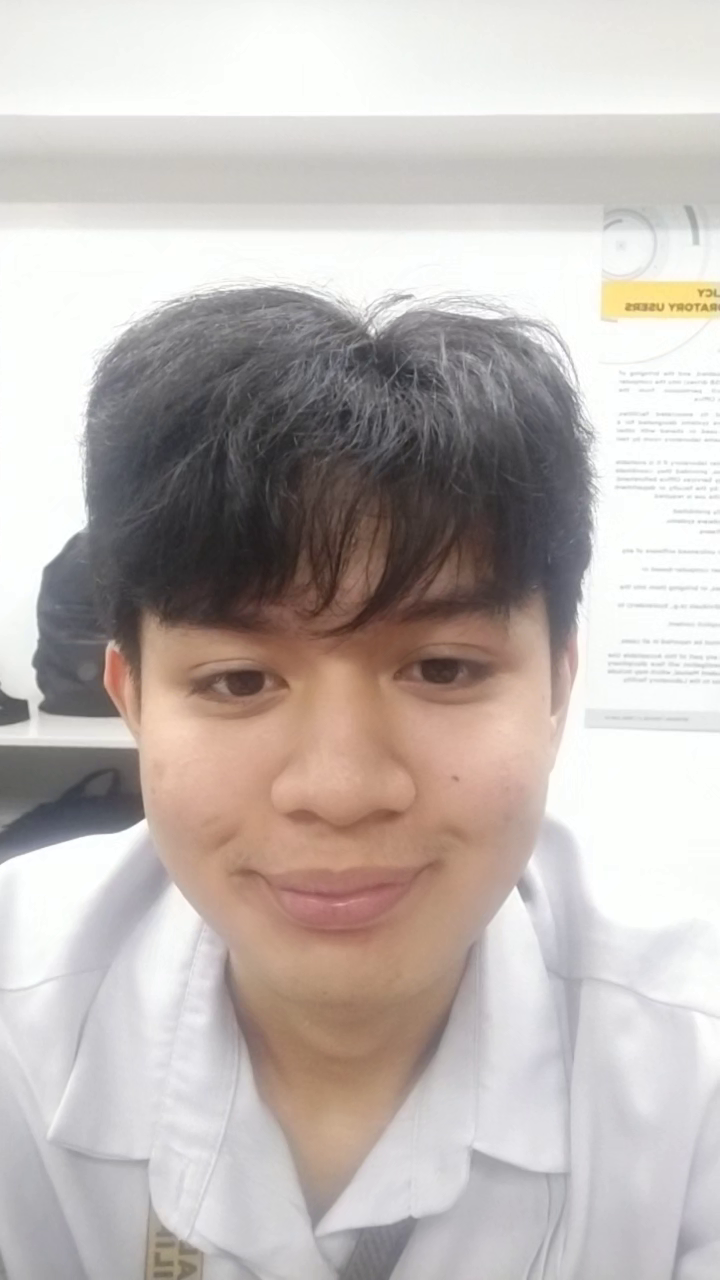

Frame 61: No faces detected.
Frame 62: No faces detected.
Frame 63: No faces detected.
Frame 64: No faces detected.
Frame 65: No faces detected.
Frame 66: No faces detected.
Frame 67: No faces detected.
Frame 68: No faces detected.
Frame 69: No faces detected.
Frame 70: Detected 1 face(s).
Frame 71: No faces detected.
Frame 72: No faces detected.
Frame 73: No faces detected.
Frame 74: No faces detected.
Frame 75: No faces detected.
Frame 76: No faces detected.
Frame 77: No faces detected.
Frame 78: No faces detected.
Frame 79: No faces detected.
Frame 80: No faces detected.
Frame 81: No faces detected.
Frame 82: No faces detected.
Frame 83: No faces detected.
Frame 84: No faces detected.
Frame 85: No faces detected.
Frame 86: No faces detected.
Frame 87: No faces detected.
Frame 88: No faces detected.
Frame 89: No faces detected.
Frame 90: No faces detected.
Displaying frame 90:


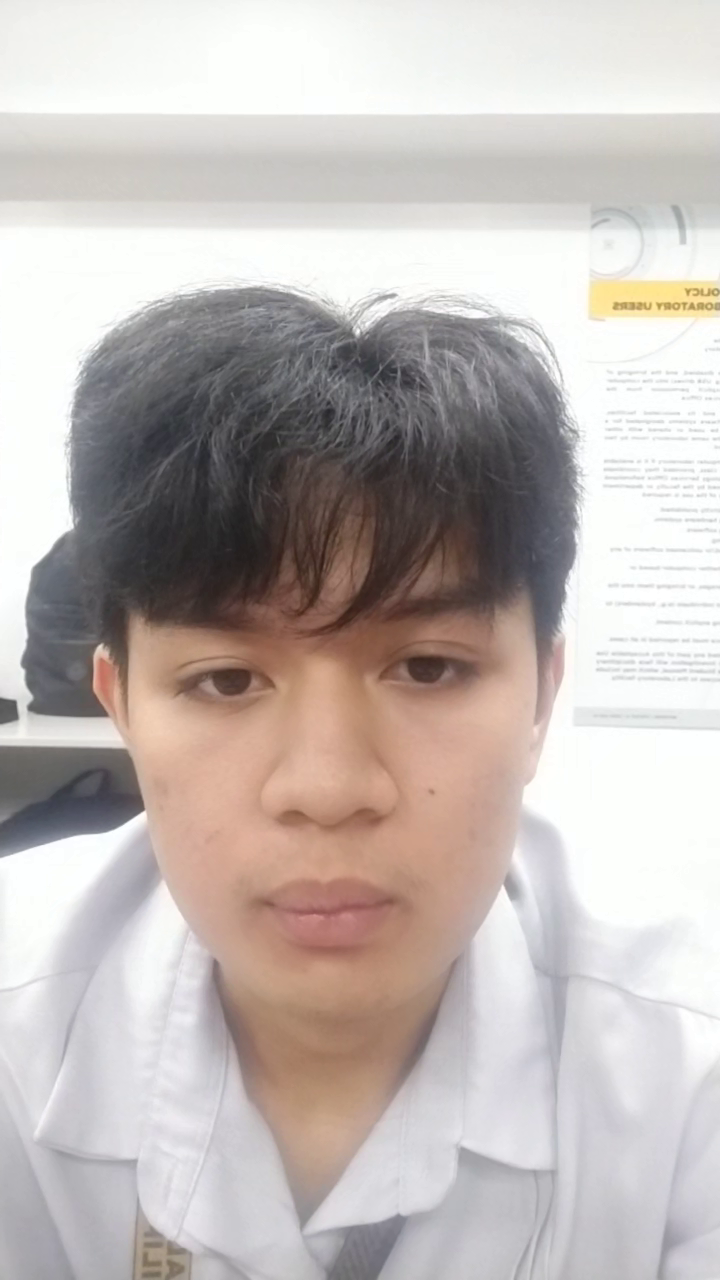

Frame 91: No faces detected.
Frame 92: No faces detected.
Frame 93: No faces detected.
Frame 94: No faces detected.
Frame 95: No faces detected.
Frame 96: No faces detected.
Frame 97: No faces detected.
Frame 98: No faces detected.
Frame 99: No faces detected.
Frame 100: No faces detected.
Frame 101: No faces detected.
Frame 102: No faces detected.
Frame 103: No faces detected.
Frame 104: No faces detected.
Frame 105: No faces detected.
Frame 106: No faces detected.
Frame 107: No faces detected.
Frame 108: No faces detected.
Frame 109: No faces detected.
Frame 110: No faces detected.
Frame 111: No faces detected.
Frame 112: No faces detected.
Frame 113: No faces detected.
Frame 114: No faces detected.
Frame 115: No faces detected.
Frame 116: No faces detected.
Frame 117: No faces detected.
Frame 118: No faces detected.
Frame 119: No faces detected.
Frame 120: No faces detected.
Displaying frame 120:


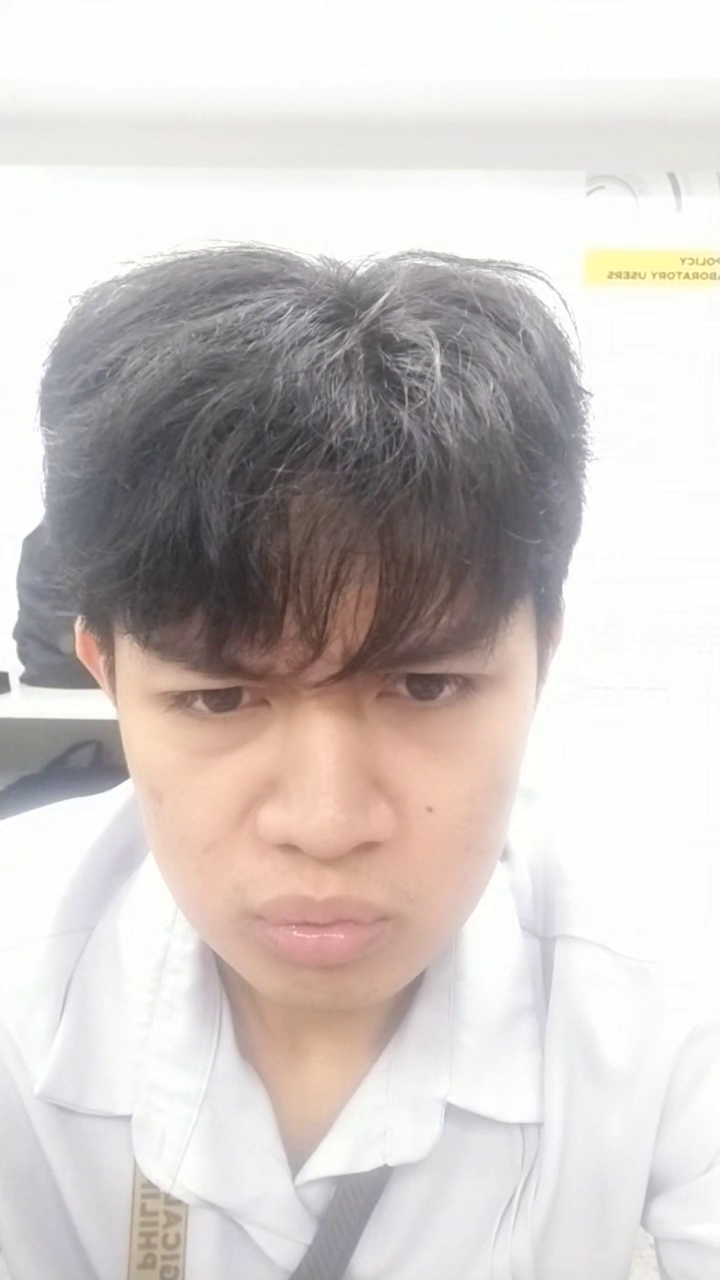

Frame 121: No faces detected.
Frame 122: No faces detected.
Frame 123: No faces detected.
Frame 124: No faces detected.
Frame 125: No faces detected.
Frame 126: No faces detected.
Frame 127: No faces detected.
Frame 128: No faces detected.
Frame 129: No faces detected.
Frame 130: No faces detected.
Frame 131: No faces detected.
Frame 132: No faces detected.
Frame 133: No faces detected.
Frame 134: No faces detected.
Frame 135: No faces detected.
Frame 136: No faces detected.
Frame 137: No faces detected.
Frame 138: No faces detected.
Frame 139: No faces detected.
Frame 140: No faces detected.
Frame 141: No faces detected.
Frame 142: No faces detected.
Frame 143: No faces detected.
Frame 144: No faces detected.
Frame 145: No faces detected.
Frame 146: No faces detected.
Frame 147: No faces detected.
Frame 148: No faces detected.
Frame 149: No faces detected.
Frame 150: No faces detected.
Displaying frame 150:


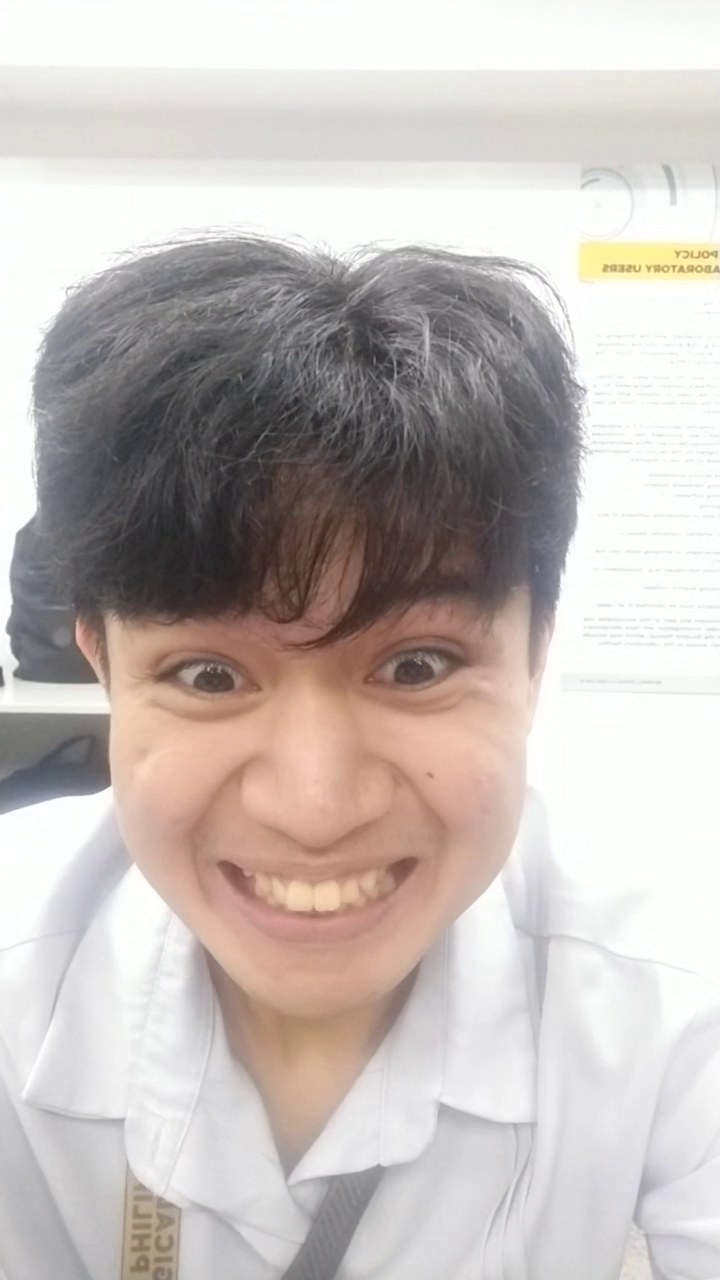

Frame 151: No faces detected.
Frame 152: No faces detected.
Frame 153: No faces detected.
Frame 154: No faces detected.
Frame 155: No faces detected.
Frame 156: No faces detected.
Frame 157: No faces detected.
Frame 158: No faces detected.
Frame 159: No faces detected.
Frame 160: No faces detected.
Frame 161: No faces detected.
Frame 162: No faces detected.
Frame 163: No faces detected.
Frame 164: No faces detected.
Frame 165: No faces detected.
Frame 166: No faces detected.
Frame 167: No faces detected.
Frame 168: No faces detected.
Frame 169: No faces detected.
Frame 170: No faces detected.
Frame 171: No faces detected.
Frame 172: No faces detected.
End of video stream or cannot read frame.


In [49]:
eye_cascade = cv2.CascadeClassifier(eye_cascade_file)

frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        print("End of video stream or cannot read frame.")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    if len(faces) > 0:
        print(f"Frame {frame_count}: Detected {len(faces)} face(s).")
    else:
        print(f"Frame {frame_count}: No faces detected.")

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)


    if frame_count % 30 == 0:
        print(f"Displaying frame {frame_count}:")
        cv2_imshow(frame)

    frame_count += 1
cap.release()

## 5. Summary, Conclusions and Lessons Learned

this was a tough activity for me, as it worked with code blocks i wasnt quite familiar with. My face in the video cant deem to be detected even though I did it numerous times.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*